<a href="https://colab.research.google.com/github/Japleen-kaur12/japleen_portfolio/blob/main/Copy_of_Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard_synthetic.csv.xlsx to creditcard_synthetic.csv (1).xlsx


In [ ]:
import pandas as pd

# If Excel:
df = pd.read_excel("creditcard_synthetic.csv (1).xlsx")

# If CSV (use this instead if needed)
# df = pd.read_csv("creditcard_synthetic.csv")

df.head()

,transaction_id,transaction_time,amount,merchant,category,card_type,location,is_international,device_type,card_present,fraud
0,100101,2026-04-01 11:20:00,145.0,Amazon,Shopping,Credit,Delhi,False,Mobile,True,0
1,100102,2026-04-01 11:22:00,22.5,Starbucks,Food,Debit,Gurgaon,False,POS,True,0
2,100103,2026-04-01 11:24:00,3100.0,Croma,Electronics,Credit,Mumbai,False,Laptop,False,0
3,100104,2026-04-01 11:26:00,54000.0,Unknown,Unknown,Credit,Berlin,True,Mobile,False,1
4,100105,2026-04-01 11:28:00,80.0,Swiggy,Food,Debit,Bangalore,False,Mobile,False,0


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(100, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    100 non-null    int64         
 1   transaction_time  100 non-null    datetime64[ns]
 2   amount            100 non-null    float64       
 3   merchant          100 non-null    object        
 4   category          100 non-null    object        
 5   card_type         100 non-null    object        
 6   location          100 non-null    object        
 7   is_international  100 non-null    bool          
 8   device_type       100 non-null    object        
 9   card_present      100 non-null    bool          
 10  fraud             100 non-null    int64         
dtypes: bool(2), datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 7.4+ KB
None
transaction_id      0
transaction_time    0
amount              0
merchant            0
c

In [ ]:
# Convert boolean columns
df['is_international'] = df['is_international'].astype(int)
df['card_present'] = df['card_present'].astype(int)

# Convert time to useful features
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour

# Drop unnecessary column
df = df.drop(columns=['transaction_time', 'transaction_id'])

# One-hot encoding (categorical → numeric)
df = pd.get_dummies(df, drop_first=True)

df.head()

,amount,is_international,card_present,fraud,hour,merchant_Big Bazaar,merchant_Croma,merchant_DMart,merchant_Flipkart,merchant_Luxury Brand,...,location_Seoul,location_Singapore,location_Sydney,location_Thailand,location_Toronto,location_Venice,location_Vienna,location_Zurich,device_type_Mobile,device_type_POS
0,145.0,0,1,0,11,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,22.5,0,1,0,11,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3100.0,0,0,0,11,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,54000.0,1,0,1,11,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,80.0,0,0,0,11,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



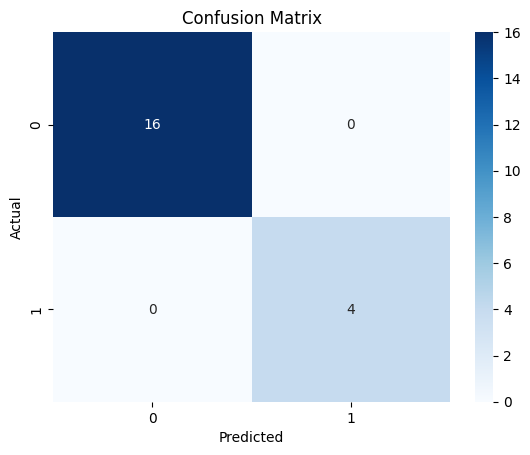

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

                  Feature  Importance
1        is_international    0.299029
22       category_Unknown    0.187552
15       merchant_Unknown    0.171962
0                  amount    0.100667
8   merchant_Luxury Brand    0.052063
2            card_present    0.021853
29         location_Delhi    0.019495
54        device_type_POS    0.014475
17       category_Fashion    0.011859
19       category_Grocery    0.009261


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

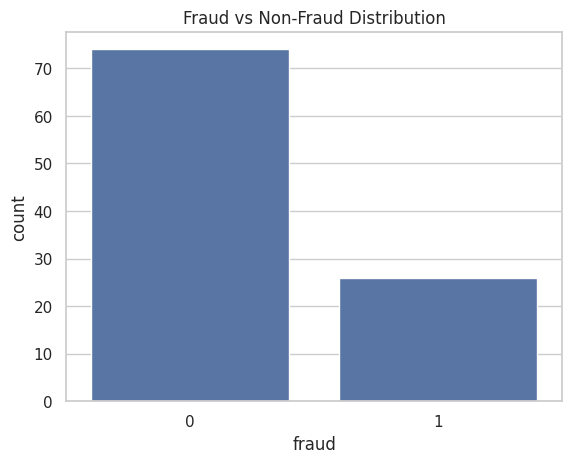

In [ ]:
sns.countplot(x='fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

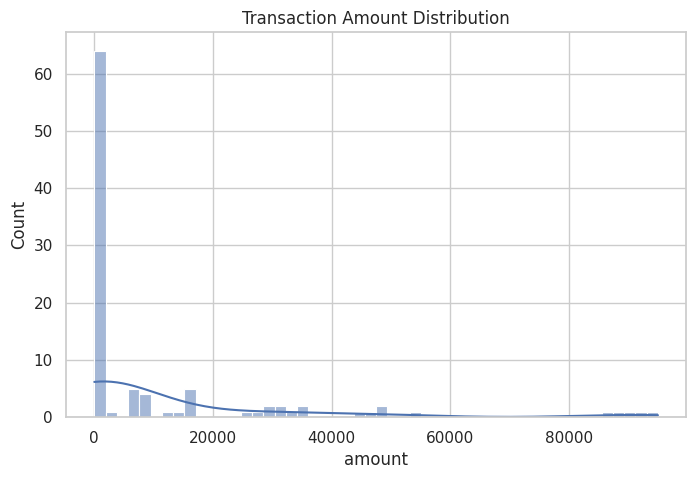

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

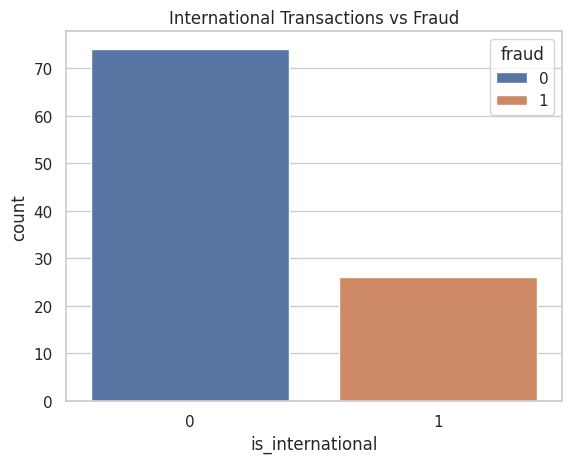

In [ ]:
sns.countplot(x='is_international', hue='fraud', data=df)
plt.title("International Transactions vs Fraud")
plt.show()

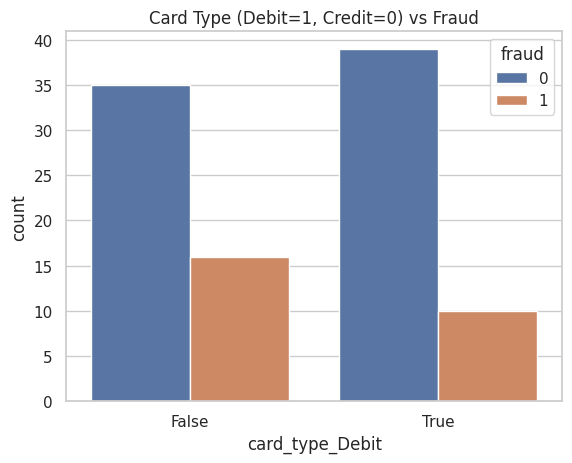

In [ ]:
sns.countplot(x='card_type_Debit', hue='fraud', data=df)
plt.title("Card Type (Debit=1, Credit=0) vs Fraud")
plt.show()

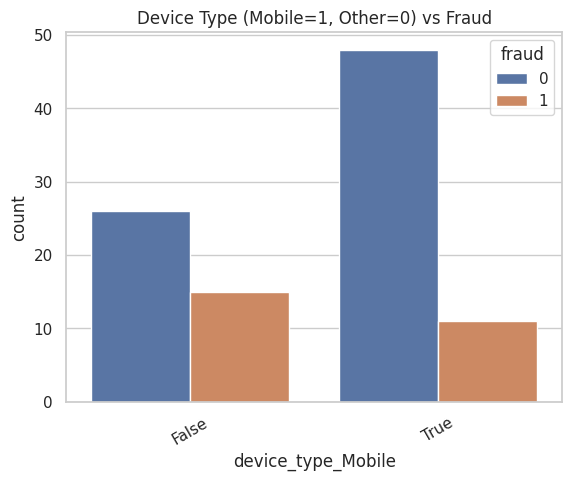

In [ ]:
sns.countplot(x='device_type_Mobile', hue='fraud', data=df)
plt.title("Device Type (Mobile=1, Other=0) vs Fraud")
plt.xticks(rotation=30)
plt.show()

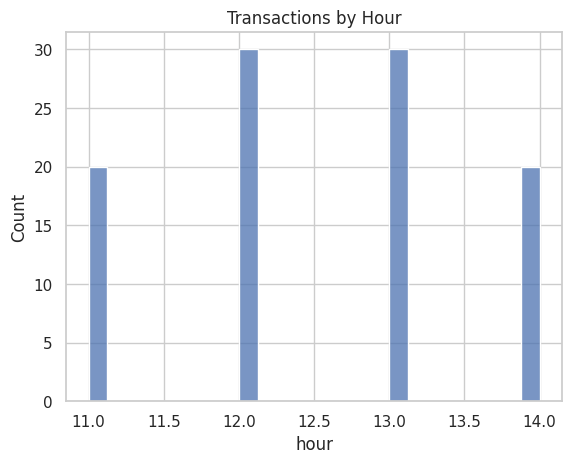

In [ ]:
sns.histplot(df['hour'], bins=24, kde=False)
plt.title("Transactions by Hour")
plt.show()

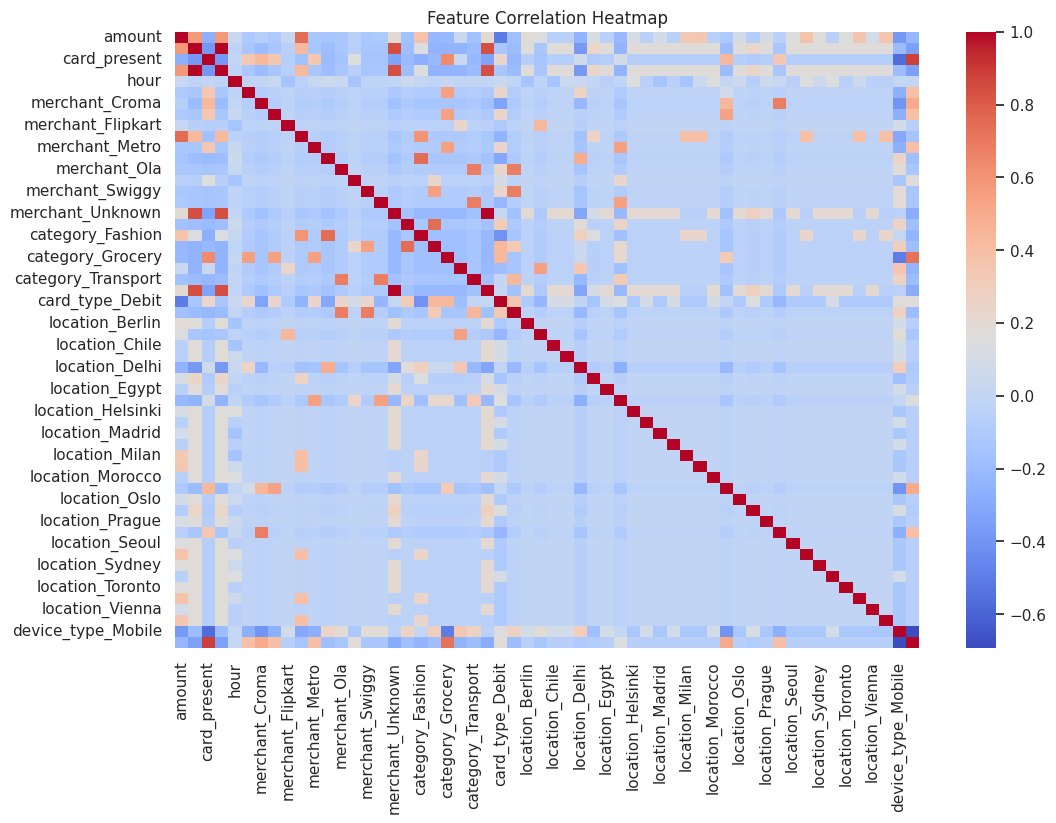

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

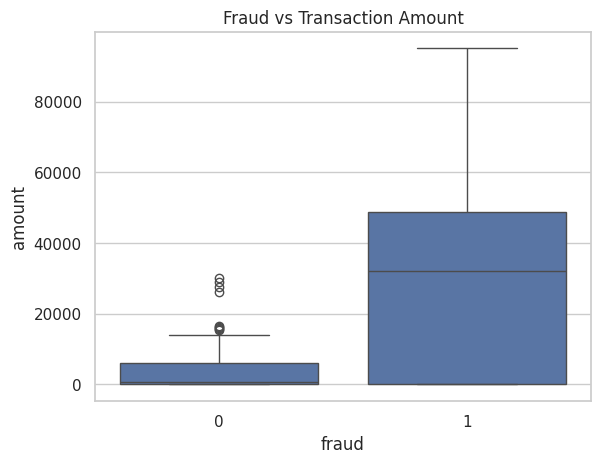

In [ ]:
sns.boxplot(x='fraud', y='amount', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

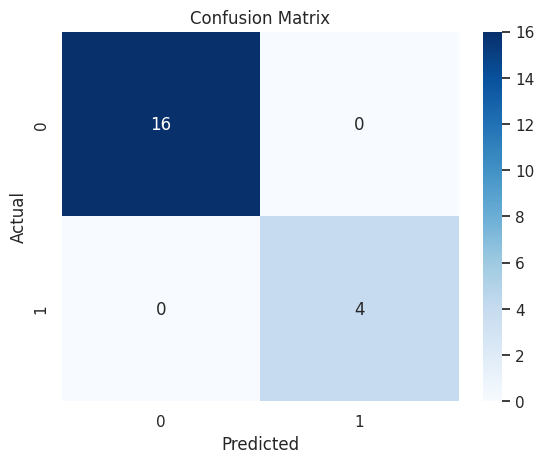

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

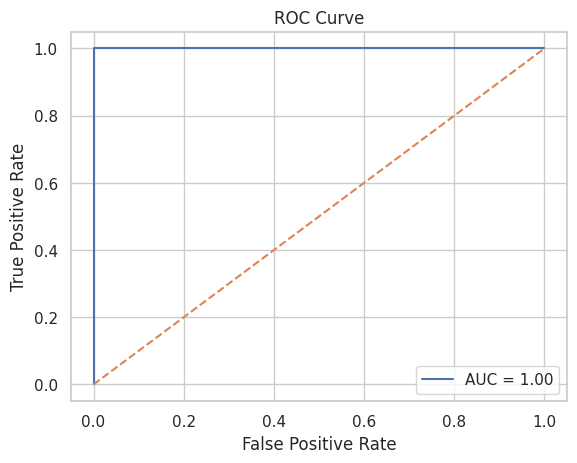

In [ ]:
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

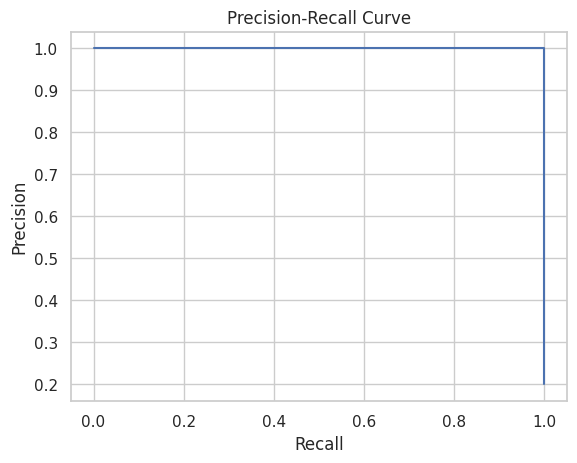

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

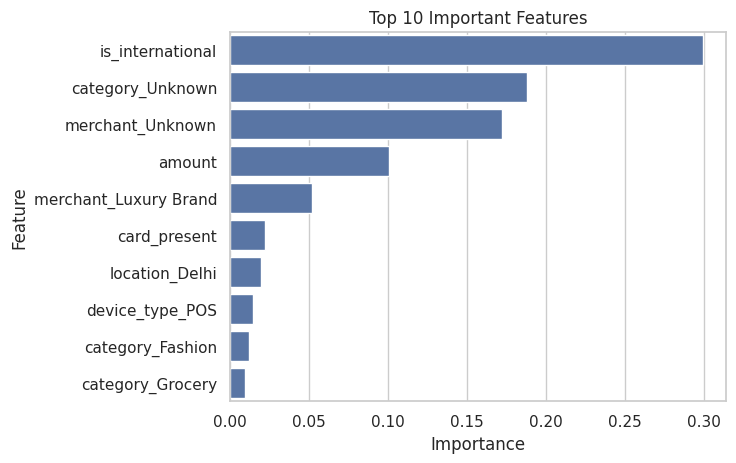

In [ ]:
import pandas as pd

importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

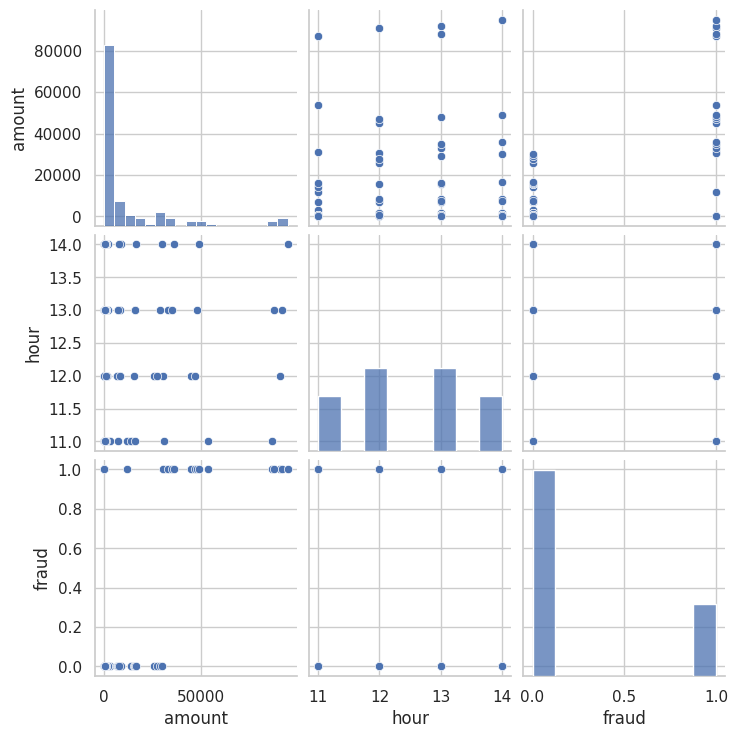

In [ ]:
sns.pairplot(df[['amount','hour','fraud']])
plt.show()

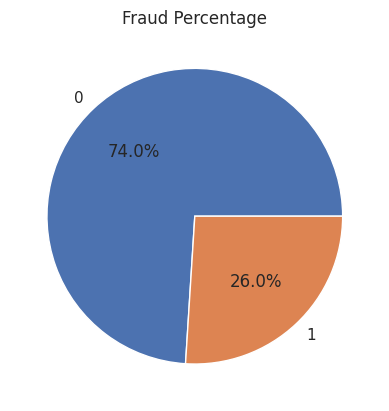

In [ ]:
df['fraud'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Fraud Percentage")
plt.ylabel("")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

🔹 Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("🔹 Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

🔹 Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🔹 Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🔹 Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

